In [54]:
header = "D:/K_sunada/result/CDY153/"

## 1/4 fogi calibration - DPR1-L-120-44

In [55]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [56]:
import sklearn
from sklearn.decomposition import PCA

## ac stark shift

In [57]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [58]:
def double_Lorentzian(freq, amp1, const, center1, k1, amp2, center2, k2):
    return const - amp1*k1**2/((freq-center1)**2 + k2**2)- amp2*k2**2/((freq-center2)**2 + k2**2)

In [59]:
ac = "/2024-01-04/2024-01-04T145816_40dd2156-42_fogi_ac_Stark_shift"
dd_ac = datadict_from_hdf5(header + ac +"/data")

xs = []
ys = []

for i in range(11):
    ini = 81*i
    fin = 81*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

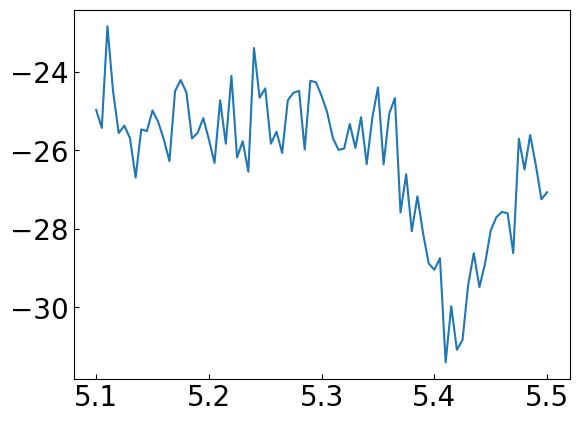

In [60]:
plt.plot(xs[0], ys[0])
plt.show()

In [61]:
par_ini = {
    'amp': 8,
    'const':-26,
    'center':5.4,
    'k':0.085
}
par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}
par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}
par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [62]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [63]:
results = []
for i in range(10):
    result = model.fit(data = ys[i], params=params, freq = xs[i])
    results.append(result)

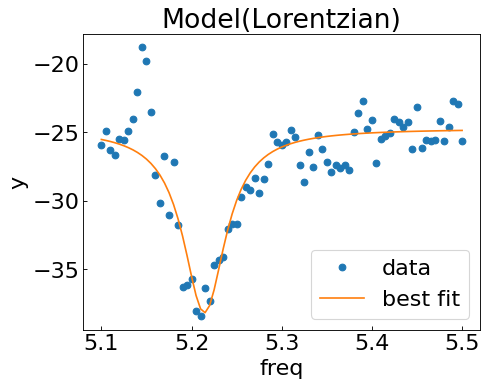

In [64]:
fig, ax = plt.subplots(dpi=80)
id = 9
results[id].plot_fit(ax = ax)
# plt.plot(xs[0],results[0].init_fit)
plt.show()
results[id]

In [75]:
xs = []
ys = []
zs = []

for i in range(10):
    ini = 81*i
    fin = 81*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['amplitude']['values'][ini:fin]
    z = np.angle(dd_ac['s11']['values'][ini:fin])
    xs.append(x)
    ys.append(y)
    zs.append(z)

In [76]:
x = dd_ac['fogi_freq']['values']
y = dd_ac['amplitude']['values']
z = np.angle(dd_ac['s11']['values'])

C:\Users\qipe\AppData\Local\Temp\ipykernel_7248\3644659728.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cm = plt.cm.get_cmap('magma')


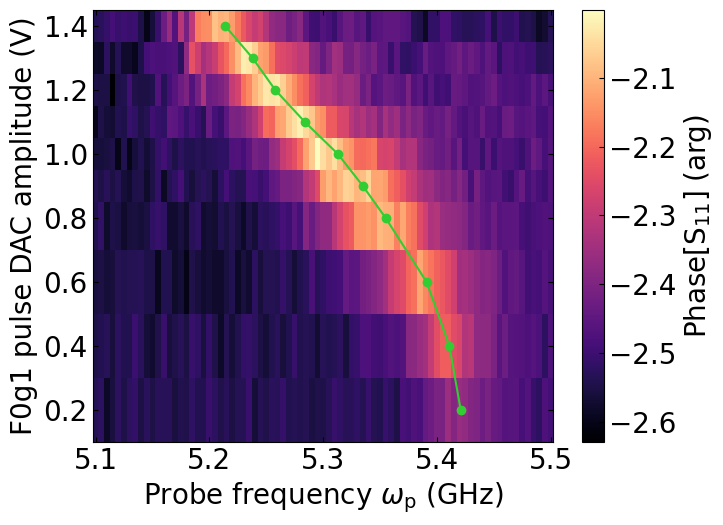

In [83]:
cm = plt.cm.get_cmap('magma')
fig= plt.figure()
plt.rcParams["font.size"] = 20
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

ax = fig.add_axes((0.1, 0.1, 0.9, 0.9))
ax.set_ylabel("F0g1 pulse DAC amplitude (V)")
ax.set_xlabel("Probe frequency $\omega_\mathrm{p}$ (GHz)")
# ax.set_xlim(-10, 20)
# ax.set_ylim(10, 10.6)

maingraph = ax.pcolormesh(xs,ys, zs, vmin=min(np.unique(z)), vmax=max(np.unique(z)), cmap=cm, shading='auto')
plt.colorbar(maingraph, label="Phase[S$_{11}$] (arg)")
plt.tick_params(top='on',bottom='on',left='on',right='on')

peak_x =[0.2, 0.4, 0.6 , 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
peak_y = [5.421, 5.411, 5.391, 5.355, 5.335, 5.313, 5.284, 5.258, 5.238, 5.214]

plt.plot(peak_y, peak_x,'-o' ,color ='limegreen')
# plt.savefig('fogi_ac_Stark.png', bbox_inches='tight')
plt.show()

In [68]:
import sklearn
from sklearn.decomposition import PCA

In [69]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [70]:
def PCA_transform1(Re_c_amp, Im_c_amp, Re_c_drag, Im_c_drag):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c_amp]).T, np.array([Im_c_amp]).T], axis = 1)
    c1_data = np.concatenate([np.array([Re_c_drag]).T, np.array([Im_c_drag]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    
    c1_pca = pca.transform(c1_data)
    c1_PCA1 = c1_pca.T[0]
    c1_PCA2 = c1_pca.T[1]
    return c_PCA1, c_PCA2, c1_PCA1, c1_PCA2,

fogi duration

In [84]:
pi_fogi = "/2024-01-04/2024-01-04T153255_18350386-41_fogi_duration_sweep"
dd = datadict_from_hdf5(header + pi_fogi +"/data")
pi_fogi1 = "/2024-01-04/2024-01-04T154033_28fc5418-41_fogi_duration_sweep"
dd1 = datadict_from_hdf5(header + pi_fogi1 +"/data")

x = np.unique(dd['fogi_duration']['values'])
ys = []
for i in range(5):
    ini = i*51
    y = np.imag(dd['s11']['values'][ini:ini+51])
    ys.append(y)

y1 = np.imag(dd1['s11']['values'][0:51])
ys.append(y1 )

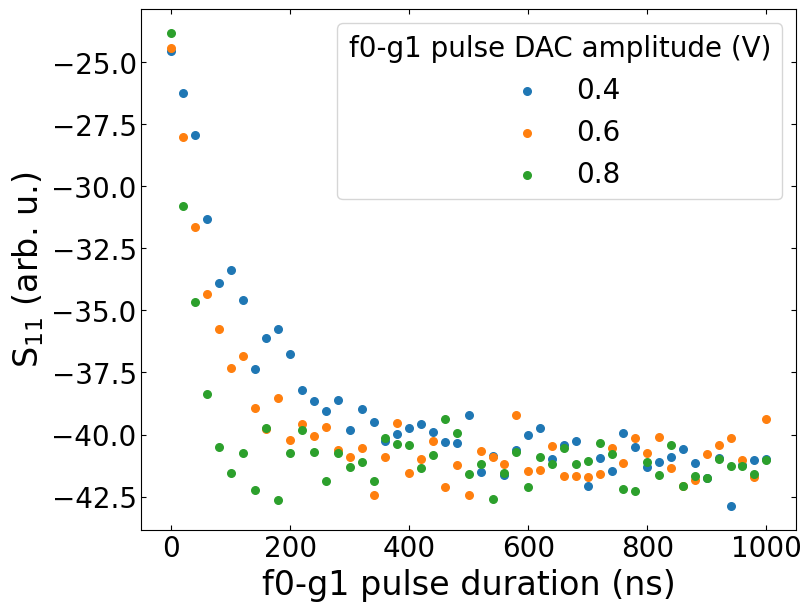

In [99]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

plt.scatter(x, ys[0], s= 30 , label = "0.4") #0.4
plt.scatter(x, ys[1], s= 30 , label = "0.6") #0.6
plt.scatter(x, ys[2], s= 30 , label = "0.8" ) #0.8
plt.title("")
legend = plt.legend()
legend.set_title("f0-g1 pulse DAC amplitude (V)")
ax.set_xlabel('f0-g1 pulse duration (ns)', size='large')
ax.set_ylabel('S$_{11}$ (arb. u.)', size='large')
# plt.savefig('fogi_duration.png', bbox_inches='tight')
plt.show()

In [73]:
kappa_e  = 250 *2*np.pi
delta_g = (10.3-5.6)*2*np.pi
delta_f =(2*8-0.3-2*5.6)*2*np.pi
Delta_d = delta_f-delta_g

g = (0.002*(10.3-5.6))**0.5*2*np.pi
Omega = 1
Delta = 8-10.3
alpha = -0.3
g_eff = (g*alpha*Omega/(2**0.5*Delta*(Delta+alpha)))**2

X = kappa_e**2/16 - Delta_d**2/4 - g_eff**2
Y = -kappa_e*Delta_d/4
X, Y

(154212.17398262708, 493.48022005447064)

In [74]:
cos = X/(X**2+Y**2)**0.5
cos2 = ((cos+1)/2)**0.5
Re1 = -kappa_e/4 + (X**2+Y**2)**0.25*cos2
Re2 = -kappa_e/4 - (X**2+Y**2)**0.25*cos2
Re1, Re2, cos2

(-2.7768010113504715e-10, -785.3981633971705, 0.9999987200024576)